In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Unemployment in India.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [4]:
df.isna().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [5]:
df.dropna(how='all', inplace=True)
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [6]:
df.columns = df.columns.str.strip()
df['Date'] = df['Date'].str.strip()
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [8]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


# the avarge of unemployment rate based on Area (Rural vs Urban)

In [10]:
area_stats = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean().reset_index()
print("\n=== the avarge of unemployment rate based on Area (Rural vs Urban) ===")
print(area_stats.round(2))


=== the avarge of unemployment rate based on Area (Rural vs Urban) ===
    Area  Estimated Unemployment Rate (%)
0  Rural                            10.32
1  Urban                            13.17


# Unemployment Rate Trend over Time

C:\Users\kareem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kareem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


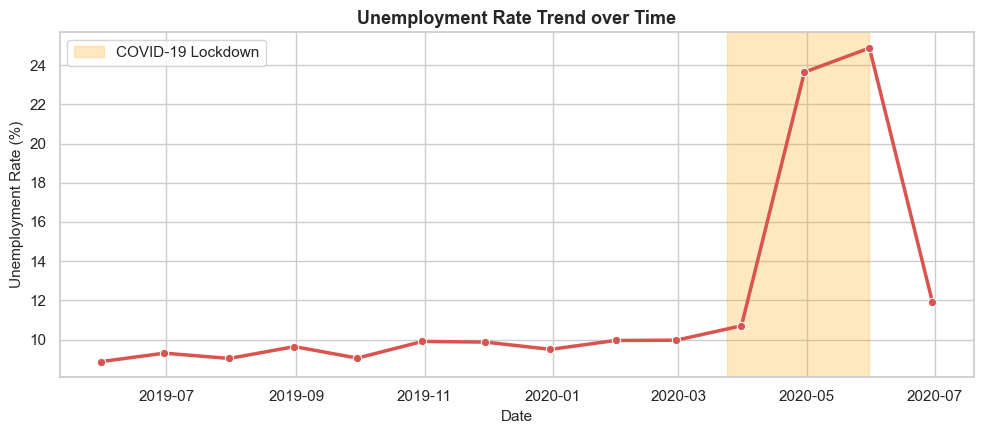

In [63]:
sns.set_theme(style='whitegrid')
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

# رسم المنحنى الزمني
plt.figure(figsize=(10, 4.5))
sns.lineplot(data=monthly_avg, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='#d9534f', linewidth=2.5)
# تظليل فترة الإغلاق العام
plt.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='orange', alpha=0.25, label='COVID-19 Lockdown')

plt.title('Unemployment Rate Trend over Time', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Unemployment Rate (%)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# Unemployment Rate: Rural vs Urban Areas over Time

C:\Users\kareem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kareem\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


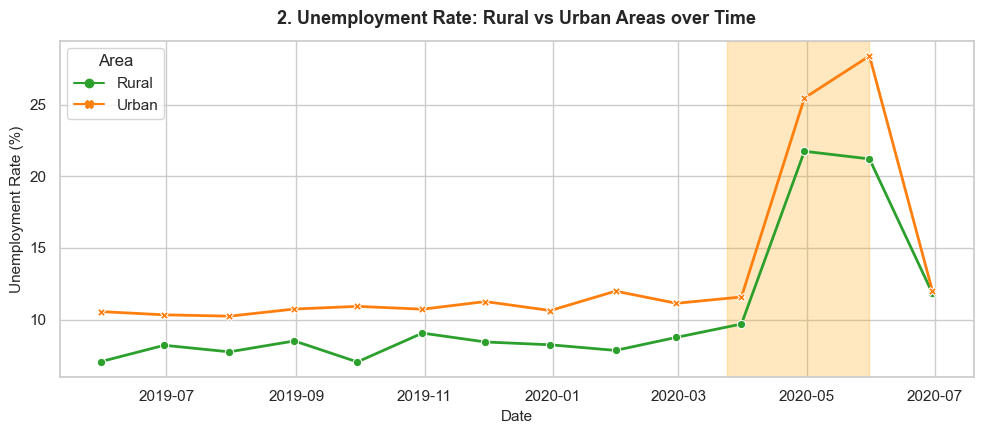

In [81]:
area_monthly = df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(10, 4.5))
sns.lineplot(data=area_monthly, x='Date', y='Estimated Unemployment Rate (%)', 
             hue='Area', style='Area', markers=True, dashes=False, 
             palette=['#2ca02c', '#ff7f0e'], linewidth=2)
plt.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='orange', alpha=0.25, label='COVID-19 Lockdown')


plt.title('2. Unemployment Rate: Rural vs Urban Areas over Time', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Unemployment Rate (%)', fontsize=11)
plt.tight_layout()
plt.show()

## Top 10 Unemployment Rate (%) in States During COVID-19 Lockdown (Apr - May 2020)

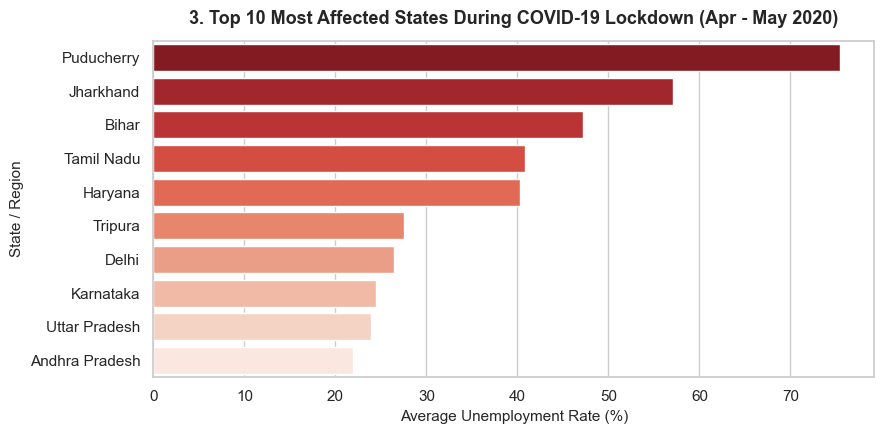

In [87]:
lockdown_df = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-05-31')]

top10_lockdown = lockdown_df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(9, 4.5))
sns.barplot(data=top10_lockdown, x='Estimated Unemployment Rate (%)', y='Region', palette='Reds_r')

plt.title('3. Top 10 Most Affected States During COVID-19 Lockdown (Apr - May 2020)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Average Unemployment Rate (%)', fontsize=11)
plt.ylabel('State / Region', fontsize=11)
plt.tight_layout()
plt.show()

## Explaining the relationship between the columns (the effect of each column on the other)

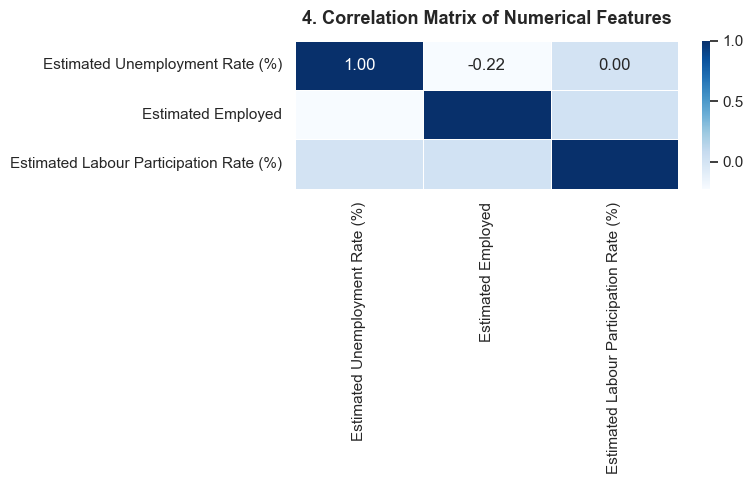

In [91]:
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']

plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)

plt.title('4. Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()